In [1]:
import torch
import numpy as np
from pathlib import Path
from data.simulations import make_gaussian_to_moons
from data.space import SpaceManager
from data.splitters import (
    SplitConfig,
    apply_holdout_masks,
    load_manifest_json,
    make_split_artifacts,
    validate_no_leakage,
)
from models.baselines import (
    NoEffectBaseline,
    ContextMeanBaseline,
    PerturbMeanBaseline,
    DecoderOnlyBaseline,
    AdditiveBaseline,
)
from evaluation.metrics import (
    compute_mmd,
    compute_energy_distance,
    compute_mse,
    compute_wasserstein_distance,
    compute_cosine_log_fc,
    precompute_true_deg_info,
    compute_deg_overlap,
    compute_perturbation_discrimination,
)
import anndata as ad
import pertpy
import scanpy as sc

/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)

cuda


In [3]:
config = SplitConfig()
artifacts = make_split_artifacts(config)

subsample_h5ad_path = Path(f"sciplex_subsample_{artifacts.tag}.h5ad")
space_path = Path(f"sciplex_space_{artifacts.tag}.pkl")
fm_model_path = Path(f"sciplex_fm_model_{artifacts.tag}.pt")
fm_metadata_path = Path(f"sciplex_fm_metadata_{artifacts.tag}.pkl")
ode_model_path = Path(f"sciplex_ode_model_{artifacts.tag}.pt")
ae_space_path = Path(f"sciplex_ae_space_{artifacts.tag}.pkl")
fm_nbae_model_path = Path(f"sciplex_fm_nbae_model_{artifacts.tag}.pt")
fm_nbae_metadata_path = Path(f"sciplex_fm_nbae_metadata_{artifacts.tag}.pkl")
ode_nbae_model_path = Path(f"sciplex_ode_nbae_model_{artifacts.tag}.pt")
ode_nbae_metadata_path = Path(f"sciplex_ode_nbae_metadata_{artifacts.tag}.pkl")

required = {
    "subsample_h5ad": subsample_h5ad_path,
    "holdout_manifest": artifacts.holdout_json_path,
    "space": space_path,
    "fm_model": fm_model_path,
    "fm_metadata": fm_metadata_path,
    "ode_model": ode_model_path,
    "ae_space": ae_space_path,
    "fm_nbae_model": fm_nbae_model_path,
    "fm_nbae_metadata": fm_nbae_metadata_path,
    "ode_nbae_model": ode_nbae_model_path,
    "ode_nbae_metadata": ode_nbae_metadata_path,
}
missing = [f"{name}: {path}" for name, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required benchmark artifacts:\n  - " + "\n  - ".join(missing))

adata = ad.read_h5ad(subsample_h5ad_path)
manifest = load_manifest_json(artifacts.holdout_json_path)
print(f"Using split tag: {artifacts.tag}")


Using split tag: strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle


In [4]:
# # umap
# adata_copy = adata.copy()
# sc.pp.normalize_total(adata_copy, target_sum=1e4)
# sc.pp.log1p(adata_copy)
# sc.pp.highly_variable_genes(adata_copy, n_top_genes=2000, subset=True)
# sc.tl.pca(adata_copy, n_comps=50)
# sc.pp.neighbors(adata_copy, n_neighbors=15, n_pcs=50)
# sc.tl.umap(adata_copy, n_components=2)

In [5]:
# cols_to_plot = ["pathway", "cell_type", "replicate", "vehicle"]

# sc.pl.umap(adata_copy, color=cols_to_plot, ncols=2)
# sc.pl.pca(adata_copy, color=cols_to_plot, ncols=2)

In [6]:
import pickle
from models.flow import CondFlow, ConditionEncoder, sample_ode

with open(fm_metadata_path, "rb") as f:
    meta = pickle.load(f)


cond_enc = ConditionEncoder(covariate_dicts=meta["covariate_dicts"], embedding_dim=64, condition_dim=128)
fm_model = CondFlow(input_dim=2000, output_dim=2000, hidden_dim=256, hidden_layers=4, cond_encoder=cond_enc).to(device)
fm_model.load_state_dict(torch.load(fm_model_path, map_location=device))
fm_model.to(device)
fm_model.eval()


class FMBaseline:
    def __init__(self, model, meta):
        self.model = model
        self.meta = meta
        self.mean = meta["mean"].to(device)
        self.std = meta["std"].to(device)

    def fit(self, x_ctrl, x_pert, cond_pert):
        # no fitting needed for pretrained model
        pass

    def sample(self, x_ctrl, cond_batch):
        """Need to use cond_batch with same vocab as training data."""
        x_pred = sample_ode(self.model, x_ctrl.to(device), cond_batch, method="rk4", time=1.0)
        return x_pred.cpu()


In [7]:
# Load ODE model (shares covariate_dicts / vocab with FM model)
ode_cond_enc = ConditionEncoder(covariate_dicts=meta["covariate_dicts"], embedding_dim=64, condition_dim=128)
ode_model = CondFlow(input_dim=2000, output_dim=2000, hidden_dim=256, hidden_layers=4, cond_encoder=ode_cond_enc).to(
    device
)
ode_model.load_state_dict(torch.load(ode_model_path, map_location=device))
ode_model.eval()


class ODEBaseline:
    def __init__(self, model):
        self.model = model

    def fit(self, x_ctrl, x_pert, cond_pert):
        pass

    def sample(self, x_ctrl, cond_batch):
        """Sample using ODE integration with adaptive RK4 solver."""
        x_pred = sample_ode(self.model, x_ctrl.to(device), cond_batch, method="rk4", time=1.0)
        return x_pred.cpu()


In [8]:
# Load NB AutoEncoder + latent-space FM/ODE models
from models.autoencoder import NBAutoEncoder

with open(ae_space_path, "rb") as f:
    ae_space = pickle.load(f)

with open(fm_nbae_metadata_path, "rb") as f:
    nbae_meta = pickle.load(f)

with open(ode_nbae_metadata_path, "rb") as f:
    ode_nbae_meta = pickle.load(f)

NBAE_LATENT_DIM = nbae_meta["latent_dim"]
ae_model = ae_space.ae_model.to(device)
ae_model.eval()

# Verify that the AE and FM spaces use identical HVGs.
assert list(ae_space.hvg_names) == list(meta["hvg_names"]), (
    "AE HVG names do not match FM HVG names — latent baselines would encode wrong genes!"
)
assert list(ae_space.hvg_names) == list(nbae_meta["hvg_names"]), (
    "AE HVG names do not match FM_NBAE HVG names — latent baselines would encode wrong genes!"
)
assert list(ae_space.hvg_names) == list(ode_nbae_meta["hvg_names"]), (
    "AE HVG names do not match ODE_NBAE HVG names — latent baselines would encode wrong genes!"
)
print(f"HVG check passed: AE and FM share the same {len(ae_space.hvg_names)} HVGs")

# Verify vocabulary compatibility across all learned models.
assert nbae_meta["pert_to_idx"] == meta["pert_to_idx"], "FM_NBAE pert_to_idx does not match FM pert_to_idx!"
assert nbae_meta["rep_to_idx"] == meta["rep_to_idx"], "FM_NBAE rep_to_idx does not match FM rep_to_idx!"
assert nbae_meta["ct_to_idx"] == meta["ct_to_idx"], "FM_NBAE ct_to_idx does not match FM ct_to_idx!"
assert ode_nbae_meta["pert_to_idx"] == meta["pert_to_idx"], "ODE_NBAE pert_to_idx does not match FM pert_to_idx!"
assert ode_nbae_meta["rep_to_idx"] == meta["rep_to_idx"], "ODE_NBAE rep_to_idx does not match FM rep_to_idx!"
assert ode_nbae_meta["ct_to_idx"] == meta["ct_to_idx"], "ODE_NBAE ct_to_idx does not match FM ct_to_idx!"
print("Vocab check passed: latent baselines and FM share identical pert/rep/ct vocabularies")

# Load FM_NBAE model
nbae_cond_enc = ConditionEncoder(covariate_dicts=nbae_meta["covariate_dicts"], embedding_dim=64, condition_dim=128)
fm_nbae_model = CondFlow(
    input_dim=NBAE_LATENT_DIM,
    output_dim=NBAE_LATENT_DIM,
    hidden_dim=256,
    hidden_layers=4,
    cond_encoder=nbae_cond_enc,
).to(device)
fm_nbae_model.load_state_dict(torch.load(fm_nbae_model_path, map_location=device))
fm_nbae_model.eval()

# Load ODE_NBAE model
ODE_NBAE_LATENT_DIM = ode_nbae_meta["latent_dim"]
assert ODE_NBAE_LATENT_DIM == NBAE_LATENT_DIM, "ODE_NBAE latent dim must match FM_NBAE latent dim."
ode_nbae_cond_enc = ConditionEncoder(
    covariate_dicts=ode_nbae_meta["covariate_dicts"], embedding_dim=64, condition_dim=128
)
ode_nbae_model = CondFlow(
    input_dim=ODE_NBAE_LATENT_DIM,
    output_dim=ODE_NBAE_LATENT_DIM,
    hidden_dim=256,
    hidden_layers=4,
    cond_encoder=ode_nbae_cond_enc,
).to(device)
ode_nbae_model.load_state_dict(torch.load(ode_nbae_model_path, map_location=device))
ode_nbae_model.eval()

print(f"Loaded NB AE ({len(ae_space.hvg_names)} genes -> {NBAE_LATENT_DIM}d), FM_NBAE, and ODE_NBAE models")


class FMNBAEBaseline:
    """Flow-matching baseline in NB autoencoder latent space."""

    def __init__(self, ae_model, fm_model, device, control_library_size=None, target_sum=1e4, sample_nb=True):
        self.ae_model = ae_model
        self.fm_model = fm_model
        self.device = device
        self.control_library_size = control_library_size
        self.target_sum = float(target_sum)
        self.sample_nb = sample_nb

    def fit(self, x_ctrl, x_pert, cond_pert):
        pass

    def sample(self, x_ctrl, cond_batch):
        """Predict perturbed expression via AE-latent flow matching."""
        self.ae_model.eval()
        self.fm_model.eval()

        x_dev = x_ctrl.to(self.device)
        with torch.no_grad():
            z_ctrl = self.ae_model.encode(x_dev)
            z_pred = sample_ode(self.fm_model, z_ctrl, cond_batch, method="rk4", time=1.0)

            if self.control_library_size is None:
                lib_size = torch.expm1(x_dev).sum(dim=1).clamp(min=1.0)
            else:
                if len(self.control_library_size) != z_pred.shape[0]:
                    raise ValueError(
                        "control_library_size length does not match x_ctrl batch size for FM_NBAE sampling."
                    )
                lib_size = self.control_library_size.to(self.device).clamp(min=1.0)

            mu, theta = self.ae_model.decode(z_pred, lib_size)

            if self.sample_nb:
                p = mu / (mu + theta + 1e-8)
                nb_counts = torch.distributions.NegativeBinomial(total_count=theta, probs=p).sample()
                sample_lib = nb_counts.sum(dim=-1, keepdim=True).clamp(min=1.0)
                x_pred_log1p = torch.log1p(nb_counts / sample_lib * self.target_sum)
            else:
                x_pred_log1p = torch.log1p(mu / lib_size.unsqueeze(-1) * self.target_sum)

        return x_pred_log1p.cpu()


class ODENBAEBaseline:
    """Neural ODE baseline in NB autoencoder latent space."""

    def __init__(self, ae_model, ode_model, device, control_library_size=None, target_sum=1e4, sample_nb=True):
        self.ae_model = ae_model
        self.ode_model = ode_model
        self.device = device
        self.control_library_size = control_library_size
        self.target_sum = float(target_sum)
        self.sample_nb = sample_nb

    def fit(self, x_ctrl, x_pert, cond_pert):
        pass

    def sample(self, x_ctrl, cond_batch):
        """Predict perturbed expression via AE-latent neural ODE transport."""
        self.ae_model.eval()
        self.ode_model.eval()

        x_dev = x_ctrl.to(self.device)
        with torch.no_grad():
            z_ctrl = self.ae_model.encode(x_dev)
            z_pred = sample_ode(self.ode_model, z_ctrl, cond_batch, method="rk4", time=1.0)

            if self.control_library_size is None:
                lib_size = torch.expm1(x_dev).sum(dim=1).clamp(min=1.0)
            else:
                if len(self.control_library_size) != z_pred.shape[0]:
                    raise ValueError(
                        "control_library_size length does not match x_ctrl batch size for ODE_NBAE sampling."
                    )
                lib_size = self.control_library_size.to(self.device).clamp(min=1.0)

            mu, theta = self.ae_model.decode(z_pred, lib_size)

            if self.sample_nb:
                p = mu / (mu + theta + 1e-8)
                nb_counts = torch.distributions.NegativeBinomial(total_count=theta, probs=p).sample()
                sample_lib = nb_counts.sum(dim=-1, keepdim=True).clamp(min=1.0)
                x_pred_log1p = torch.log1p(nb_counts / sample_lib * self.target_sum)
            else:
                x_pred_log1p = torch.log1p(mu / lib_size.unsqueeze(-1) * self.target_sum)

        return x_pred_log1p.cpu()


HVG check passed: AE and FM share the same 2000 HVGs
Vocab check passed: latent baselines and FM share identical pert/rep/ct vocabularies
Loaded NB AE (2000 genes -> 128d), FM_NBAE, and ODE_NBAE models


In [9]:
hvg_names = meta["hvg_names"]
adata_hvg = adata[:, hvg_names].copy()

rep_to_idx = meta["rep_to_idx"]
ct_to_idx = meta["ct_to_idx"]
pert_to_idx = meta["pert_to_idx"]


In [10]:
with open(space_path, "rb") as f:
    space = pickle.load(f)


In [11]:
is_ctrl = adata_hvg.obs["vehicle"] == 1
is_pert_any = adata_hvg.obs["vehicle"] == 0

x_ctrl = space.to_latent(adata_hvg[is_ctrl])
x_pert_all = space.to_latent(adata_hvg[is_pert_any])

from sklearn.decomposition import PCA

combined_real_data = torch.cat([x_ctrl, x_pert_all], dim=0).numpy()
global_pca = PCA(n_components=50)
global_pca.fit(combined_real_data)
print(f"fit global PCA on {combined_real_data.shape} to {global_pca.n_components_} components")
pca_mean = torch.from_numpy(global_pca.mean_).to(device, dtype=torch.float32)
pca_components = torch.from_numpy(global_pca.components_).to(device, dtype=torch.float32)


def project_fast(x, mean, components):
    x_centered = x - mean
    return (x.to(device) - mean) @ components.T


print(x_ctrl.shape, x_pert_all.shape)

/nfs/roberts/scratch/pi_sk2433/dac227/FlatCFM/data/space.py:85: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(curr_adata, target_sum=self.target_sum)


fit global PCA on (100000, 2000) to 50 components
torch.Size([2196, 2000]) torch.Size([97804, 2000])


In [12]:
def make_cond_dict(pert_ids, replicate_ids, cell_type_ids):
    """Build a condition dict matching the FM model's expected format.

    Args:
        pert_ids: Perturbation index tensor.
        replicate_ids: Replicate index tensor.
        cell_type_ids: Cell type index tensor.

    Returns:
        Condition dict with perturbation and sample covariate keys.
    """
    return {
        "perturbations": pert_ids,
        "perturbation_covariates": {},
        "sample_covariates": {"replicate": replicate_ids, "cell_type": cell_type_ids},
    }


SEED = config.seed
test_cell_type = config.test_cell_type

masks = apply_holdout_masks(adata_hvg, manifest)
validate_no_leakage(adata_hvg, masks, product_name_col="product_name")

is_held_out = masks["is_held_out"]
is_pert_any = masks["is_pert_any"]
is_pert_train = masks["is_pert_train"]

held_out_product_names = set(manifest["selected_holdout_product_names"])
print(f"Holding out {len(held_out_product_names)} product_names selected from {test_cell_type}")
print(
    f"Train pert cells: {is_pert_train.sum()}, Held-out pert cells (global): {is_held_out.sum()}, "
    f"Held-out {test_cell_type}: {(is_held_out & (adata_hvg.obs['cell_type'] == test_cell_type)).sum()}"
)

# ---- Control test set ----
is_ctrl_test = is_ctrl & (adata_hvg.obs["cell_type"] == test_cell_type)
x_ctrl_test = space.to_latent(adata_hvg[is_ctrl_test])
n_ctrl_test = x_ctrl_test.shape[0]

# Build AE-style controls directly from raw counts for FM_NBAE (matches training notebook preprocessing).
adata_ctrl_test_hvg = adata_hvg[is_ctrl_test].copy()
X_ctrl_test_raw = (
    adata_ctrl_test_hvg.X.toarray() if hasattr(adata_ctrl_test_hvg.X, "toarray") else adata_ctrl_test_hvg.X
)
X_ctrl_test_t = torch.tensor(X_ctrl_test_raw, dtype=torch.float32)
ctrl_test_lib_size = X_ctrl_test_t.sum(dim=1).clamp(min=1.0)
x_ctrl_test_nbae = torch.log1p(X_ctrl_test_t / ctrl_test_lib_size.unsqueeze(-1) * 1e4)

max_abs_diff = (x_ctrl_test_nbae - x_ctrl_test).abs().max().item()
print(f"x_ctrl_test preprocess check (AE-style vs space.to_latent) max abs diff: {max_abs_diff:.3e}")

# ---- Training perturbed data (for baseline fitting) ----
x_pert_train = space.to_latent(adata_hvg[is_pert_train])
pert_train_obs = adata_hvg[is_pert_train].obs
cond_pert_train = make_cond_dict(
    torch.tensor([pert_to_idx[p] for p in pert_train_obs["product_dose"]], dtype=torch.long),
    torch.tensor([rep_to_idx[r] for r in pert_train_obs["replicate"]], dtype=torch.long),
    torch.tensor([ct_to_idx[c] for c in pert_train_obs["cell_type"]], dtype=torch.long),
)
print(f"x_pert_train: {x_pert_train.shape}, x_ctrl_test: {x_ctrl_test.shape}")

# ---- Build eval_perts (4-tuples) on held-out K562 only ----
ctrl_test_rep_ids = torch.tensor(
    [rep_to_idx[r] for r in adata_hvg[is_ctrl_test].obs["replicate"].values], dtype=torch.long
)
ctrl_test_ct_ids = torch.tensor(
    [ct_to_idx[c] for c in adata_hvg[is_ctrl_test].obs["cell_type"].values], dtype=torch.long
)

held_out_eval_mask = is_held_out & (adata_hvg.obs["cell_type"] == test_cell_type)
held_out_dose_strs = sorted(adata_hvg.obs.loc[held_out_eval_mask, "product_dose"].unique())
eval_perts = []
skipped = []
for pd_str in held_out_dose_strs:
    if pd_str not in pert_to_idx:
        skipped.append(pd_str)
        continue
    is_this = held_out_eval_mask & (adata_hvg.obs["product_dose"] == pd_str)
    if is_this.sum() == 0:
        skipped.append(pd_str)
        continue
    x_gt = space.to_latent(adata_hvg[is_this])
    dose_float = float(pd_str.rsplit("_", 1)[1])
    cond = make_cond_dict(
        torch.full((n_ctrl_test,), pert_to_idx[pd_str], dtype=torch.long),
        ctrl_test_rep_ids,
        ctrl_test_ct_ids,
    )
    eval_perts.append((pd_str, cond, x_gt, dose_float))

if skipped:
    print(f"Skipped {len(skipped)} product_doses not in pert_to_idx: {skipped[:5]}...")
print(f"Evaluating {len(eval_perts)} held-out product_doses from {len(held_out_product_names)} drug names")


Holding out 94 product_names selected from K562
Train pert cells: 48951, Held-out pert cells (global): 48853, Held-out K562: 12225
x_ctrl_test preprocess check (AE-style vs space.to_latent) max abs diff: 4.768e-07
x_pert_train: torch.Size([48951, 2000]), x_ctrl_test: torch.Size([568, 2000])


/nfs/roberts/scratch/pi_sk2433/dac227/FlatCFM/data/space.py:85: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(curr_adata, target_sum=self.target_sum)
/nfs/roberts/scratch/pi_sk2433/dac227/FlatCFM/data/space.py:85: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(curr_adata, target_sum=self.target_sum)
/nfs/roberts/scratch/pi_sk2433/dac227/FlatCFM/data/space.py:85: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(curr_adata, target_sum=self.target_sum)
/nfs/roberts/scratch/pi_sk2433/dac227/FlatCFM/data/space.py:85: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(curr_adata, target_sum=self.target_sum)


Evaluating 375 held-out product_doses from 94 drug names


In [13]:
# ── Precompute true DEG info for each held-out product_dose ───────────────────
# Done once here so the eval loop never recomputes ground-truth DEGs.
# DEGs are identified via Welch t-test (pert vs test-set ctrl), BH correction,
# FDR < 0.05, ranked by absolute log fold change.

x_ctrl_arr = x_ctrl_test.numpy()  # (n_ctrl, n_genes) — reused throughout

true_deg_infos = {}
for pd_str, cond, x_gt, dose_float in eval_perts:
    true_deg_infos[pd_str] = precompute_true_deg_info(x_gt.numpy(), x_ctrl_arr)

n_with_degs = sum(1 for v in true_deg_infos.values() if v["n_sig"] > 0)
avg_n_sig = np.mean([v["n_sig"] for v in true_deg_infos.values()])
print(
    f"Precomputed DEG info for {len(true_deg_infos)} product_doses: {n_with_degs} have ≥1 DEG, mean N={avg_n_sig:.1f}"
)


Precomputed DEG info for 375 product_doses: 373 have ≥1 DEG, mean N=79.9


In [14]:
n_features = x_ctrl_test.shape[1]

# Baselines
baselines = {
    "NoEffect": NoEffectBaseline(),
    "ContextMean": ContextMeanBaseline(),
    "PerturbMean": PerturbMeanBaseline(),
    "Decoder": DecoderOnlyBaseline(input_dim=n_features, output_dim=n_features),
    "Additive": AdditiveBaseline(),
    "FM": FMBaseline(fm_model, meta),
    "ODE": ODEBaseline(ode_model),
    "FM_NBAE": FMNBAEBaseline(
        ae_model,
        fm_nbae_model,
        device,
        control_library_size=ctrl_test_lib_size,
        target_sum=1e4,
        sample_nb=True,
    ),
    "ODE_NBAE": ODENBAEBaseline(
        ae_model,
        ode_nbae_model,
        device,
        control_library_size=ctrl_test_lib_size,
        target_sum=1e4,
        sample_nb=True,
    ),
}

x_ctrl_test_pca = project_fast(x_ctrl_test.to(device), pca_mean, pca_components)

results = {}
for name, model in baselines.items():
    model.fit(x_ctrl, x_pert_train, cond_pert_train)
    results[name] = {}
    for pd_str, cond, x_gt, dose_float in eval_perts:
        x_ctrl_input = x_ctrl_test_nbae if name in {"FM_NBAE", "ODE_NBAE"} else x_ctrl_test
        x_pred = model.sample(x_ctrl_input, cond)

        x_pred_pca = project_fast(x_pred.to(device), pca_mean, pca_components)
        x_gt_pca = project_fast(x_gt.to(device), pca_mean, pca_components)

        x_pred_np = x_pred.detach().numpy()
        deg_overlaps = compute_deg_overlap(x_pred_np, x_ctrl_arr, true_deg_infos[pd_str])

        results[name][pd_str] = {
            "MMD (PCA)": compute_mmd(x_pred_pca, x_gt_pca),
            "Energy (PCA)": compute_energy_distance(x_pred_pca, x_gt_pca),
            "MSE": compute_mse(x_pred, x_gt),
            "W2 (PCA)": compute_wasserstein_distance(x_pred_pca, x_gt_pca),
            "CosineLogFC": compute_cosine_log_fc(x_pred, x_gt, x_ctrl_input),
            **deg_overlaps,
            "dose": dose_float,
            "x_pred": x_pred_np,
            "x_gt": x_gt.detach().numpy(),
        }
    print(f"  {name}: done ({len(results[name])} perts)")


  NoEffect: done (375 perts)
  ContextMean: done (375 perts)
  PerturbMean: done (375 perts)
  Decoder: done (375 perts)
  Additive: done (375 perts)
  FM: done (375 perts)
  ODE: done (375 perts)
  FM_NBAE: done (375 perts)
  ODE_NBAE: done (375 perts)


In [15]:
# Print summary table
header = f"{'Baseline':<18} | {'product_dose':<45} | {'Dose':>7} | {'MMD':<9} | {'Energy':<9} | {'MSE':<9} | {'W2':<9} | {'CosineLogFC':<9}"
print(header)
print("-" * len(header))
for name, pert_results in results.items():
    for pd_str, scores in pert_results.items():
        print(
            f"{name:<18} | {pd_str:<45} | {scores['dose']:>7.0f} | "
            f"{scores['MMD (PCA)']:<9.4f} | {scores['Energy (PCA)']:<9.4f} | {scores['MSE']:<9.4f} | {scores['W2 (PCA)']:<9.4f} | {scores['CosineLogFC']:<9.4f}"
        )

Baseline           | product_dose                                  |    Dose | MMD       | Energy    | MSE       | W2        | CosineLogFC
------------------------------------------------------------------------------------------------------------------------------------------
NoEffect           | AG-490 (Tyrphostin B42)_10                    |      10 | 0.0121    | 0.6343    | 0.0166    | 15.8550   | 0.0000   
NoEffect           | AG-490 (Tyrphostin B42)_100                   |     100 | 0.0117    | 0.5905    | 0.0152    | 15.4408   | 0.0000   
NoEffect           | AG-490 (Tyrphostin B42)_1000                  |    1000 | 0.0063    | 0.3835    | 0.0107    | 15.2081   | 0.0000   
NoEffect           | AG-490 (Tyrphostin B42)_10000                 |   10000 | 0.0123    | 0.6131    | 0.0165    | 15.1555   | 0.0000   
NoEffect           | AMG-900_10                                    |      10 | 0.0317    | 1.3598    | 0.0248    | 16.4924   | 0.0000   
NoEffect           | AMG-900_100     

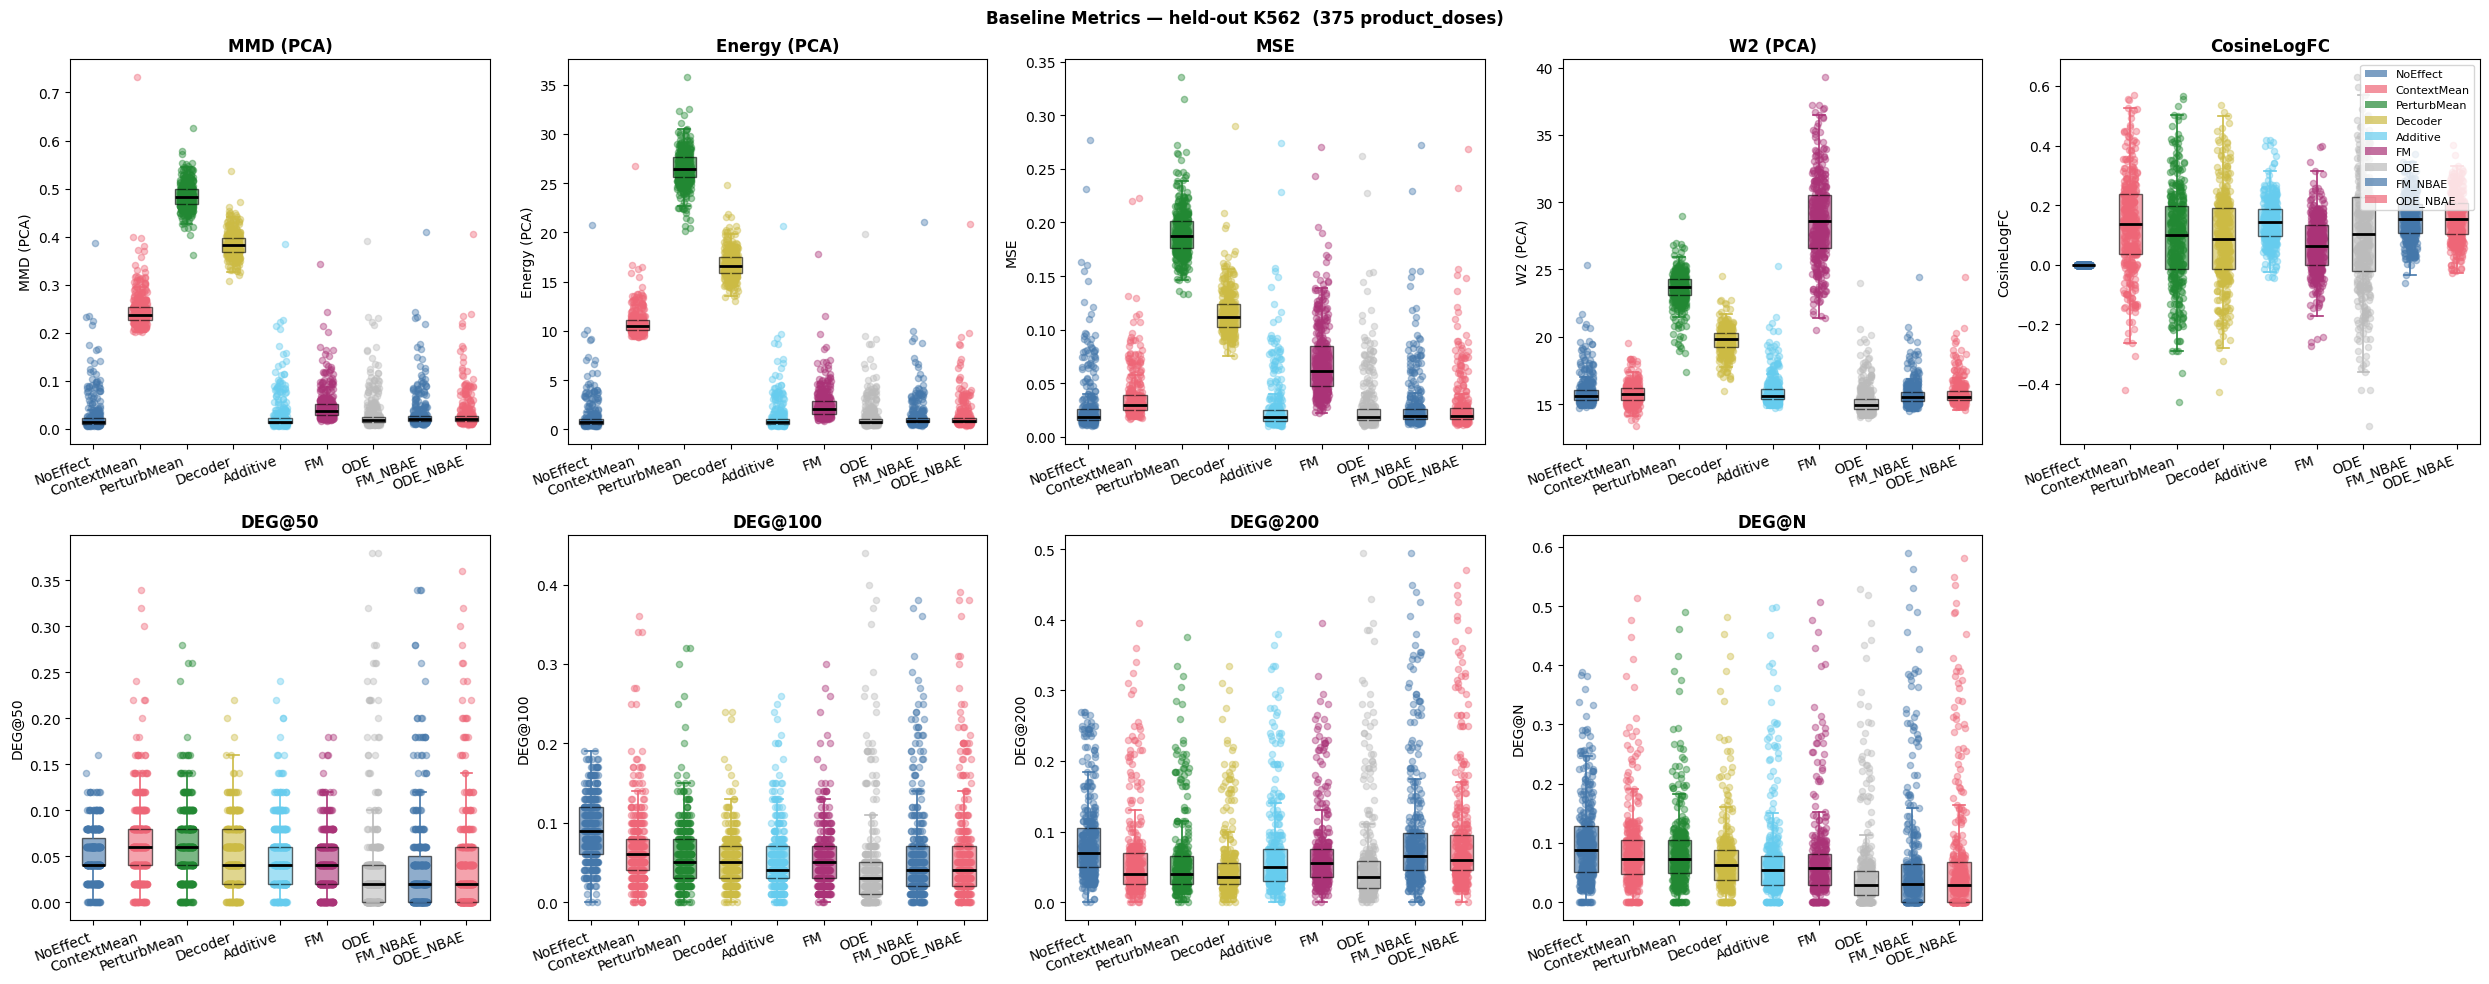

,MMD (PCA),Energy (PCA),MSE,W2 (PCA),CosineLogFC,DEG@50,DEG@100,DEG@200,DEG@N,PDisNorm
Model,,,,,,,,,,
NoEffect,"0.0275 [0.0238, 0.0317]","1.2700 [1.1113, 1.4549]","0.0291 [0.0263, 0.0321]","15.9750 [15.8636, 16.1012]","0.0000 [0.0000, 0.0000]","0.0518 [0.0490, 0.0548]","0.0933 [0.0892, 0.0974]","0.0883 [0.0823, 0.0946]","0.1018 [0.0944, 0.1094]",0.9711
ContextMean,"0.2463 [0.2426, 0.2505]","10.8247 [10.6914, 10.9752]","0.0377 [0.0355, 0.0401]","15.8088 [15.7303, 15.8867]","0.1351 [0.1198, 0.1522]","0.0655 [0.0606, 0.0703]","0.0664 [0.0615, 0.0716]","0.0623 [0.0559, 0.0690]","0.0874 [0.0799, 0.0954]",0.6054
PerturbMean,"0.4849 [0.4822, 0.4876]","26.5467 [26.3556, 26.7238]","0.1901 [0.1877, 0.1925]","23.6149 [23.4801, 23.7397]","0.0916 [0.0758, 0.1094]","0.0618 [0.0574, 0.0661]","0.0610 [0.0565, 0.0656]","0.0592 [0.0534, 0.0653]","0.0858 [0.0787, 0.0933]",-0.9594
Decoder,"0.3840 [0.3814, 0.3866]","16.7848 [16.6359, 16.9222]","0.1157 [0.1137, 0.1178]","19.7663 [19.6628, 19.8634]","0.0859 [0.0708, 0.1022]","0.0524 [0.0489, 0.0559]","0.0537 [0.0503, 0.0573]","0.0516 [0.0464, 0.0571]","0.0731 [0.0668, 0.0800]",-0.9520
Additive,"0.0271 [0.0236, 0.0312]","1.2538 [1.0981, 1.4347]","0.0285 [0.0257, 0.0315]","15.9651 [15.8570, 16.0874]","0.1459 [0.1386, 0.1538]","0.0518 [0.0481, 0.0557]","0.0536 [0.0495, 0.0581]","0.0691 [0.0625, 0.0761]","0.0714 [0.0634, 0.0798]",0.9711
FM,"0.0477 [0.0444, 0.0514]","2.5040 [2.3523, 2.6757]","0.0708 [0.0674, 0.0745]","28.6314 [28.3063, 28.9569]","0.0653 [0.0555, 0.0749]","0.0412 [0.0380, 0.0446]","0.0561 [0.0519, 0.0604]","0.0696 [0.0636, 0.0759]","0.0722 [0.0643, 0.0805]",-0.6827
ODE,"0.0304 [0.0267, 0.0344]","1.3087 [1.1570, 1.4841]","0.0287 [0.0260, 0.0316]","15.2541 [15.1480, 15.3723]","0.1012 [0.0830, 0.1212]","0.0389 [0.0332, 0.0451]","0.0453 [0.0391, 0.0521]","0.0582 [0.0506, 0.0660]","0.0535 [0.0450, 0.0627]",0.9838
FM_NBAE,"0.0317 [0.0281, 0.0359]","1.3427 [1.1877, 1.5215]","0.0294 [0.0267, 0.0323]","15.7649 [15.6708, 15.8732]","0.1544 [0.1478, 0.1621]","0.0412 [0.0358, 0.0474]","0.0592 [0.0527, 0.0662]","0.0920 [0.0836, 0.1008]","0.0655 [0.0554, 0.0763]",0.9638
ODE_NBAE,"0.0315 [0.0280, 0.0356]","1.3395 [1.1861, 1.5183]","0.0294 [0.0267, 0.0323]","15.8243 [15.7302, 15.9293]","0.1583 [0.1508, 0.1667]","0.0418 [0.0362, 0.0479]","0.0592 [0.0525, 0.0662]","0.0902 [0.0817, 0.0993]","0.0649 [0.0541, 0.0760]",0.9620


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

dist_metrics = ["MMD (PCA)", "Energy (PCA)", "MSE", "W2 (PCA)", "CosineLogFC"]
deg_metrics = ["DEG@50", "DEG@100", "DEG@200", "DEG@N"]
metrics = dist_metrics + deg_metrics
baseline_names = list(results.keys())
all_pd_strs = list(next(iter(results.values())).keys())

MODEL_COLORS = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377", "#BBBBBB"]
colors = {name: MODEL_COLORS[i % len(MODEL_COLORS)] for i, name in enumerate(baseline_names)}

fig, axes = plt.subplots(
    2, max(len(dist_metrics), len(deg_metrics)), figsize=(5 * max(len(dist_metrics), len(deg_metrics)), 10)
)

for row, row_metrics in enumerate([dist_metrics, deg_metrics]):
    for col, metric in enumerate(row_metrics):
        ax = axes[row, col]
        data_per_baseline = [[results[name][pd_str][metric] for pd_str in all_pd_strs] for name in baseline_names]
        positions = np.arange(len(baseline_names))

        for i, (name, vals) in enumerate(zip(baseline_names, data_per_baseline)):
            color = colors[name]
            ax.boxplot(
                [vals],
                positions=[positions[i]],
                widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.6),
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(color=color, linewidth=1.2),
                capprops=dict(color=color, linewidth=1.2),
                flierprops=dict(marker=""),
                zorder=2,
            )

            dot_rng = np.random.default_rng(i)
            jitter = dot_rng.uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(positions[i] + jitter, vals, s=20, alpha=0.4, color=color, zorder=1)

        ax.set_title(metric, fontweight="bold")
        ax.set_xticks(positions)
        ax.set_xticklabels(baseline_names, rotation=20, ha="right")
        ax.set_ylabel(metric)

    # Hide unused axes in this row
    for col in range(len(row_metrics), axes.shape[1]):
        axes[row, col].set_visible(False)

legend_patches = [mpatches.Patch(facecolor=colors[n], alpha=0.7, label=n) for n in baseline_names]
axes[0, -1].legend(handles=legend_patches, fontsize=8, loc="upper right")

plt.suptitle(
    f"Baseline Metrics — held-out {test_cell_type}  ({len(all_pd_strs)} product_doses)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


# ── Summary table with bootstrap 95% CIs ──────────────────────────────────────
def bootstrap_ci(vals: np.ndarray, n_boot: int = 2000, ci: float = 0.95) -> tuple:
    """Bootstrap CI for the mean.

    Args:
        vals: 1-D array of observed per-perturbation metric values.
        n_boot: Number of bootstrap resamples.
        ci: Confidence level (0–1).

    Returns:
        Tuple of (lower, upper) CI bounds.
    """
    rng = np.random.default_rng(42)
    boot_means = np.array([rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(n_boot)])
    alpha = (1 - ci) / 2
    return float(np.quantile(boot_means, alpha)), float(np.quantile(boot_means, 1 - alpha))


# lower = better for distribution metrics; higher = better for similarity/overlap metrics
higher_is_better = {"CosineLogFC", "DEG@50", "DEG@100", "DEG@200", "DEG@N", "PDisNorm"}

table_data = {}
raw_means = {}  # for finding best model per metric

for metric in metrics:
    col_entries = {}
    means = {}
    for name in baseline_names:
        vals = np.array([results[name][pd_str][metric] for pd_str in all_pd_strs])
        m = vals.mean()
        lo, hi = bootstrap_ci(vals)
        col_entries[name] = f"{m:.4f} [{lo:.4f}, {hi:.4f}]"
        means[name] = m
    table_data[metric] = col_entries
    raw_means[metric] = means

# ── PDisNorm (global metric, one scalar per model) ────────────────────────────
pdis_scores = {}
for name in baseline_names:
    pert_profiles = {}
    for pd_str, scores in results[name].items():
        pred_mean = scores["x_pred"].mean(axis=0)
        gt_mean = scores["x_gt"].mean(axis=0)
        pert_profiles[pd_str] = (pred_mean, gt_mean)
    pdis_scores[name] = compute_perturbation_discrimination(pert_profiles)

table_data["PDisNorm"] = {name: f"{pdis_scores[name]:.4f}" for name in baseline_names}
raw_means["PDisNorm"] = pdis_scores

all_table_metrics = metrics + ["PDisNorm"]
df_table = pd.DataFrame(table_data, index=baseline_names)
df_table.index.name = "Model"

# Identify best model per metric
best = {}
for metric in all_table_metrics:
    means = raw_means[metric]
    if metric in higher_is_better:
        best[metric] = max(means, key=means.get)
    else:
        best[metric] = min(means, key=means.get)


def bold_best(val, model, metric):
    if model == best[metric]:
        return "font-weight: bold; background-color: #d4f1d4"
    return ""


styled = (
    df_table.style.apply(lambda col: [bold_best(v, idx, col.name) for idx, v in col.items()], axis=0)
    .set_caption(
        f"Mean [95% bootstrap CI] — held-out {test_cell_type} ({len(all_pd_strs)} product_doses). "
        "PDisNorm is a global score (1=perfect, 0=random). Bold = best model per metric."
    )
    .set_table_styles(
        [
            {"selector": "caption", "props": [("font-size", "12px"), ("font-weight", "bold"), ("text-align", "left")]},
            {"selector": "th", "props": [("text-align", "center"), ("font-size", "11px")]},
            {"selector": "td", "props": [("text-align", "center"), ("font-size", "11px"), ("white-space", "nowrap")]},
        ]
    )
)

display(styled)

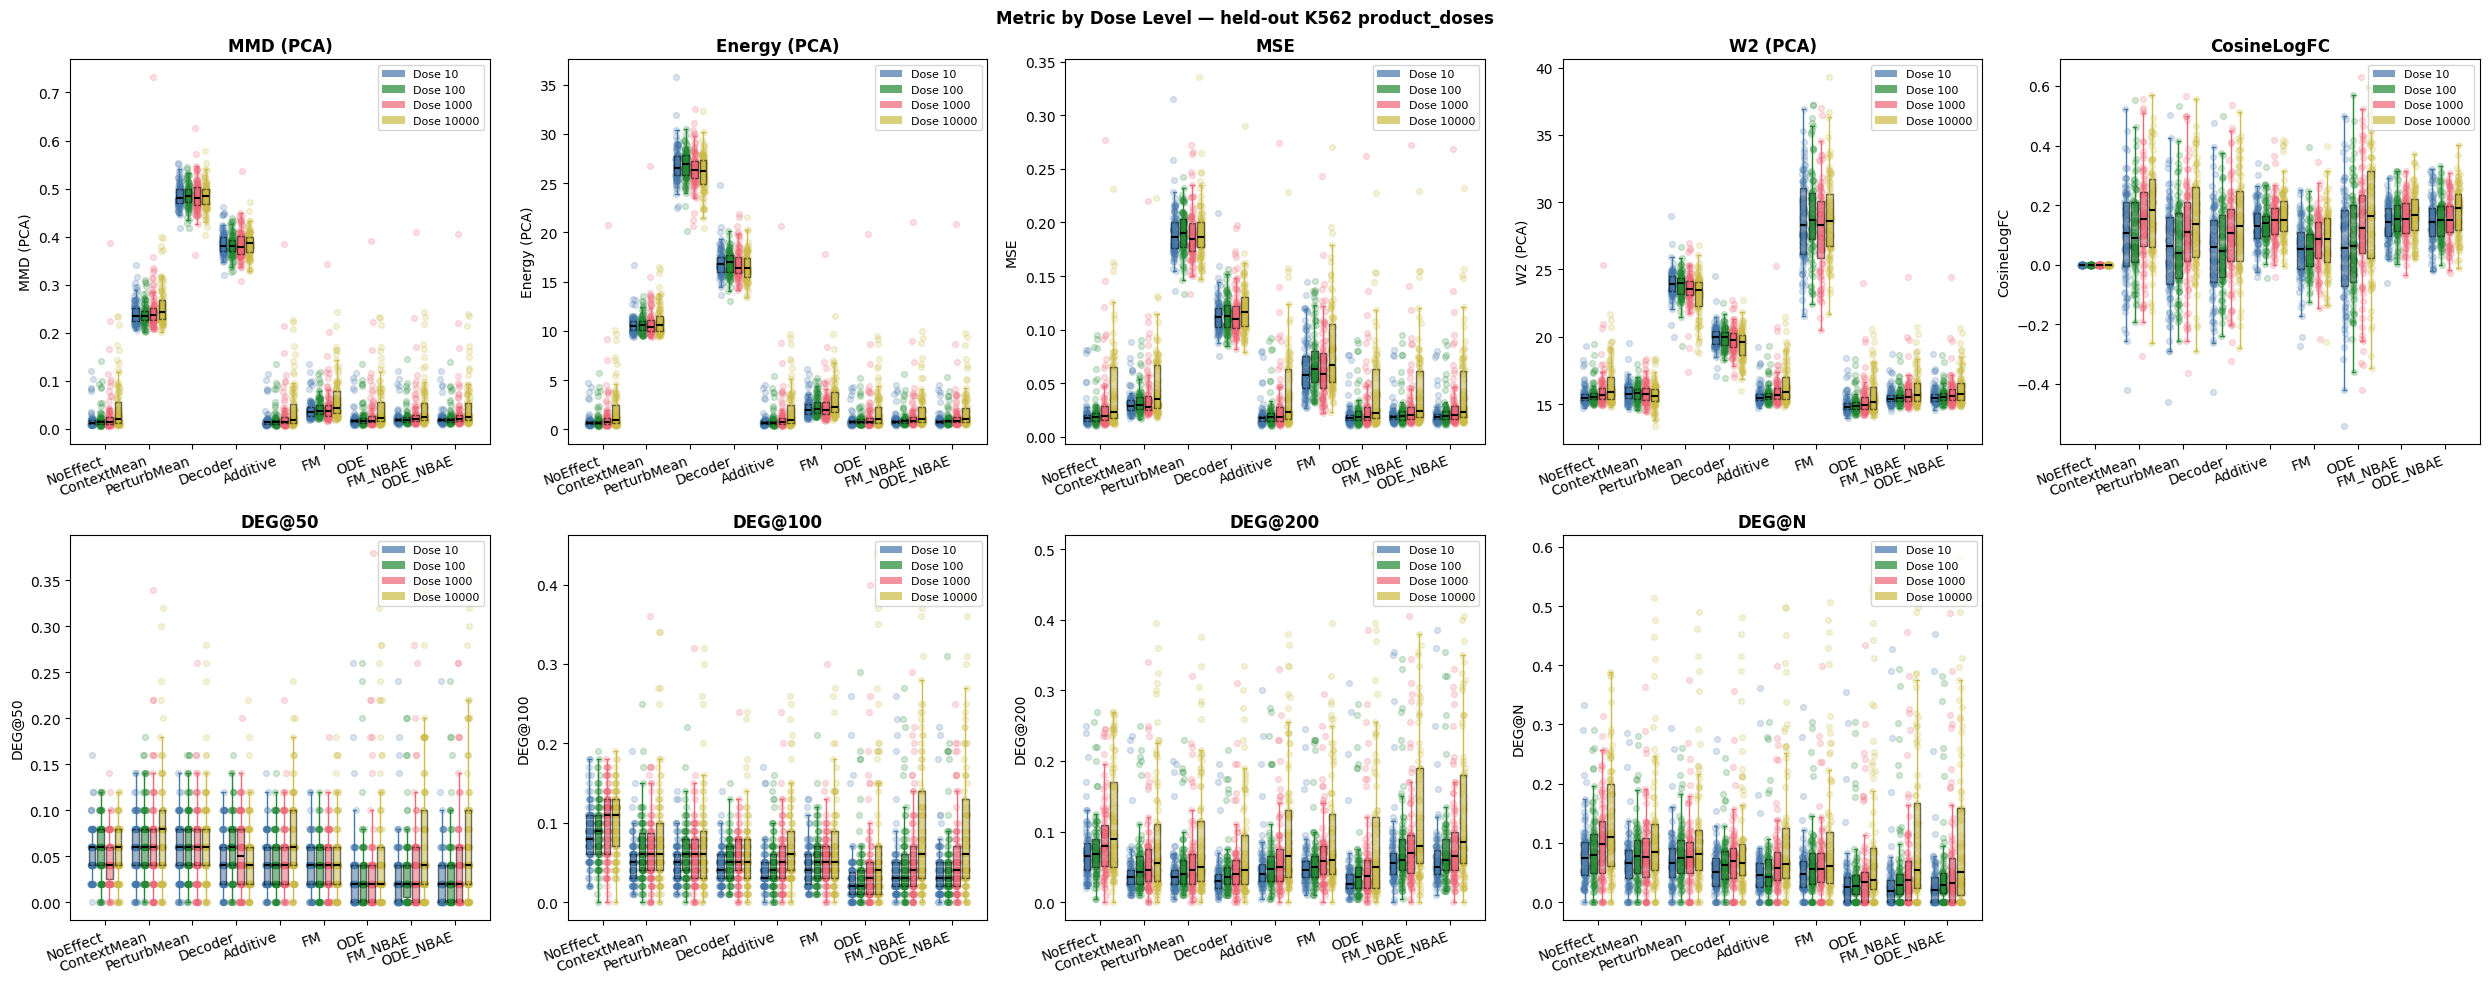

In [17]:
import matplotlib.patches as mpatches

DOSE_LEVELS = [10.0, 100.0, 1000.0, 10000.0]
DOSE_COLORS = {10.0: "#4477AA", 100.0: "#228833", 1000.0: "#EE6677", 10000.0: "#CCBB44"}
GROUP_WIDTH = 0.8
BOX_WIDTH = GROUP_WIDTH / len(DOSE_LEVELS)

dist_metrics = ["MMD (PCA)", "Energy (PCA)", "MSE", "W2 (PCA)", "CosineLogFC"]
deg_metrics = ["DEG@50", "DEG@100", "DEG@200", "DEG@N"]
metrics = dist_metrics + deg_metrics
baseline_names = list(results.keys())

n_cols = max(len(dist_metrics), len(deg_metrics))
fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 10))

for row, row_metrics in enumerate([dist_metrics, deg_metrics]):
    for col, metric in enumerate(row_metrics):
        ax = axes[row, col]
        legend_patches = []

        for j, dose in enumerate(DOSE_LEVELS):
            color = DOSE_COLORS[dose]
            offset = (j - (len(DOSE_LEVELS) - 1) / 2) * BOX_WIDTH

            positions, vals_per_pos = [], []
            for i, name in enumerate(baseline_names):
                vals = [
                    results[name][pd_str][metric] for pd_str in results[name] if results[name][pd_str]["dose"] == dose
                ]
                if vals:
                    positions.append(i + offset)
                    vals_per_pos.append(vals)

            if not positions:
                continue

            ax.boxplot(
                vals_per_pos,
                positions=positions,
                widths=BOX_WIDTH * 0.75,
                patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.55),
                medianprops=dict(color="black", linewidth=1.5),
                whiskerprops=dict(color=color, linewidth=1.0),
                capprops=dict(color=color, linewidth=1.0),
                flierprops=dict(marker=""),
                zorder=2,
            )

            dot_rng = np.random.default_rng(int(dose))
            for pos, vals in zip(positions, vals_per_pos):
                jitter = dot_rng.uniform(-BOX_WIDTH * 0.18, BOX_WIDTH * 0.18, size=len(vals))
                ax.scatter(pos + jitter, vals, s=18, alpha=0.2, color=color, zorder=1)

            legend_patches.append(mpatches.Patch(facecolor=color, alpha=0.7, label=f"Dose {int(dose)}"))

        ax.set_title(metric, fontweight="bold")
        ax.set_xticks(np.arange(len(baseline_names)))
        ax.set_xticklabels(baseline_names, rotation=20, ha="right")
        ax.set_ylabel(metric)
        ax.legend(handles=legend_patches, fontsize=8, loc="upper right")

    # Hide unused axes in this row
    for col in range(len(row_metrics), n_cols):
        axes[row, col].set_visible(False)

plt.suptitle(
    f"Metric by Dose Level — held-out {test_cell_type} product_doses",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

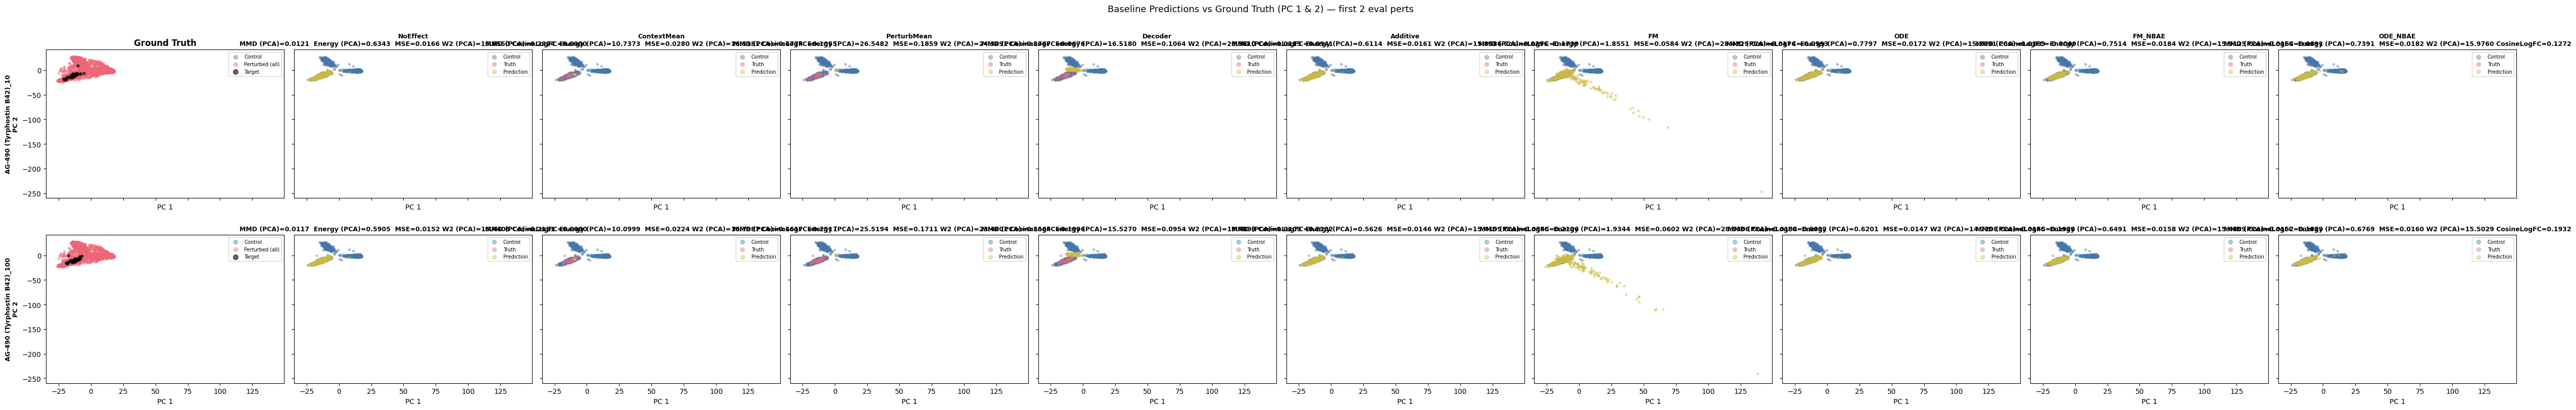

In [18]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Limit PCA grid to first 2 eval_perts to keep the figure readable
_pca_eval_perts = eval_perts[:2]
pert_names = [ep[0] for ep in _pca_eval_perts]

# Fit PCA on all data combined so all panels share the same projection
pca = PCA(n_components=2)
all_data = np.vstack(
    [x_ctrl.numpy(), x_pert_all.numpy()] + [results[name][pn]["x_pred"] for name in results for pn in pert_names]
)
pca.fit(all_data)


def proj(arr):
    return pca.transform(arr)


x_ctrl_pc = proj(x_ctrl.numpy())
x_pert_all_pc = proj(x_pert_all.numpy())

baseline_names = list(results.keys())
n_rows = len(pert_names)
n_cols = len(baseline_names) + 1  # +1 for ground truth

COLORS = {"Control": "#4477AA", "Perturbation (truth)": "#EE6677", "Prediction": "#CCBB44"}
alpha = 0.4
s = 8

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row, pert_name in enumerate(pert_names):
    ax = axes[row, 0]
    ax.scatter(x_ctrl_pc[:, 0], x_ctrl_pc[:, 1], c=COLORS["Control"], s=s, alpha=alpha, label="Control")
    ax.scatter(
        x_pert_all_pc[:, 0],
        x_pert_all_pc[:, 1],
        c=COLORS["Perturbation (truth)"],
        s=s,
        alpha=alpha,
        label="Perturbed (all)",
    )
    gt_pc = proj(next(iter(results.values()))[pert_name]["x_gt"])
    ax.scatter(gt_pc[:, 0], gt_pc[:, 1], c="black", s=s + 4, alpha=0.6, label=f"Target", zorder=3)
    if row == 0:
        ax.set_title("Ground Truth", fontsize=12, fontweight="bold")
    ax.set_ylabel(pert_name[:30], fontsize=9, fontweight="bold")
    ax.set_xlabel("PC 1")
    ax.legend(loc="upper right", markerscale=2, fontsize=7)

    for col, name in enumerate(baseline_names):
        ax = axes[row, col + 1]
        scores = results[name][pert_name]
        gt_pc = proj(scores["x_gt"])
        pred_pc = proj(scores["x_pred"])
        ax.scatter(x_ctrl_pc[:, 0], x_ctrl_pc[:, 1], c=COLORS["Control"], s=s, alpha=alpha, label="Control")
        ax.scatter(gt_pc[:, 0], gt_pc[:, 1], c=COLORS["Perturbation (truth)"], s=s, alpha=alpha, label="Truth")
        ax.scatter(pred_pc[:, 0], pred_pc[:, 1], c=COLORS["Prediction"], s=s, alpha=alpha, label="Prediction")
        title = name if row == 0 else ""
        ax.set_title(
            f"{title}\nMMD (PCA)={scores['MMD (PCA)']:.4f}  Energy (PCA)={scores['Energy (PCA)']:.4f}  MSE={scores['MSE']:.4f} W2 (PCA)={scores['W2 (PCA)']:.4f} CosineLogFC={scores['CosineLogFC']:.4f}",
            fontsize=9,
            fontweight="bold",
        )
        ax.set_xlabel("PC 1")
        ax.legend(loc="upper right", markerscale=2, fontsize=7)

for ax in axes[:, 0]:
    ax.set_ylabel(ax.get_ylabel() + "\nPC 2", fontsize=9)

plt.suptitle("Baseline Predictions vs Ground Truth (PC 1 & 2) — first 2 eval perts", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


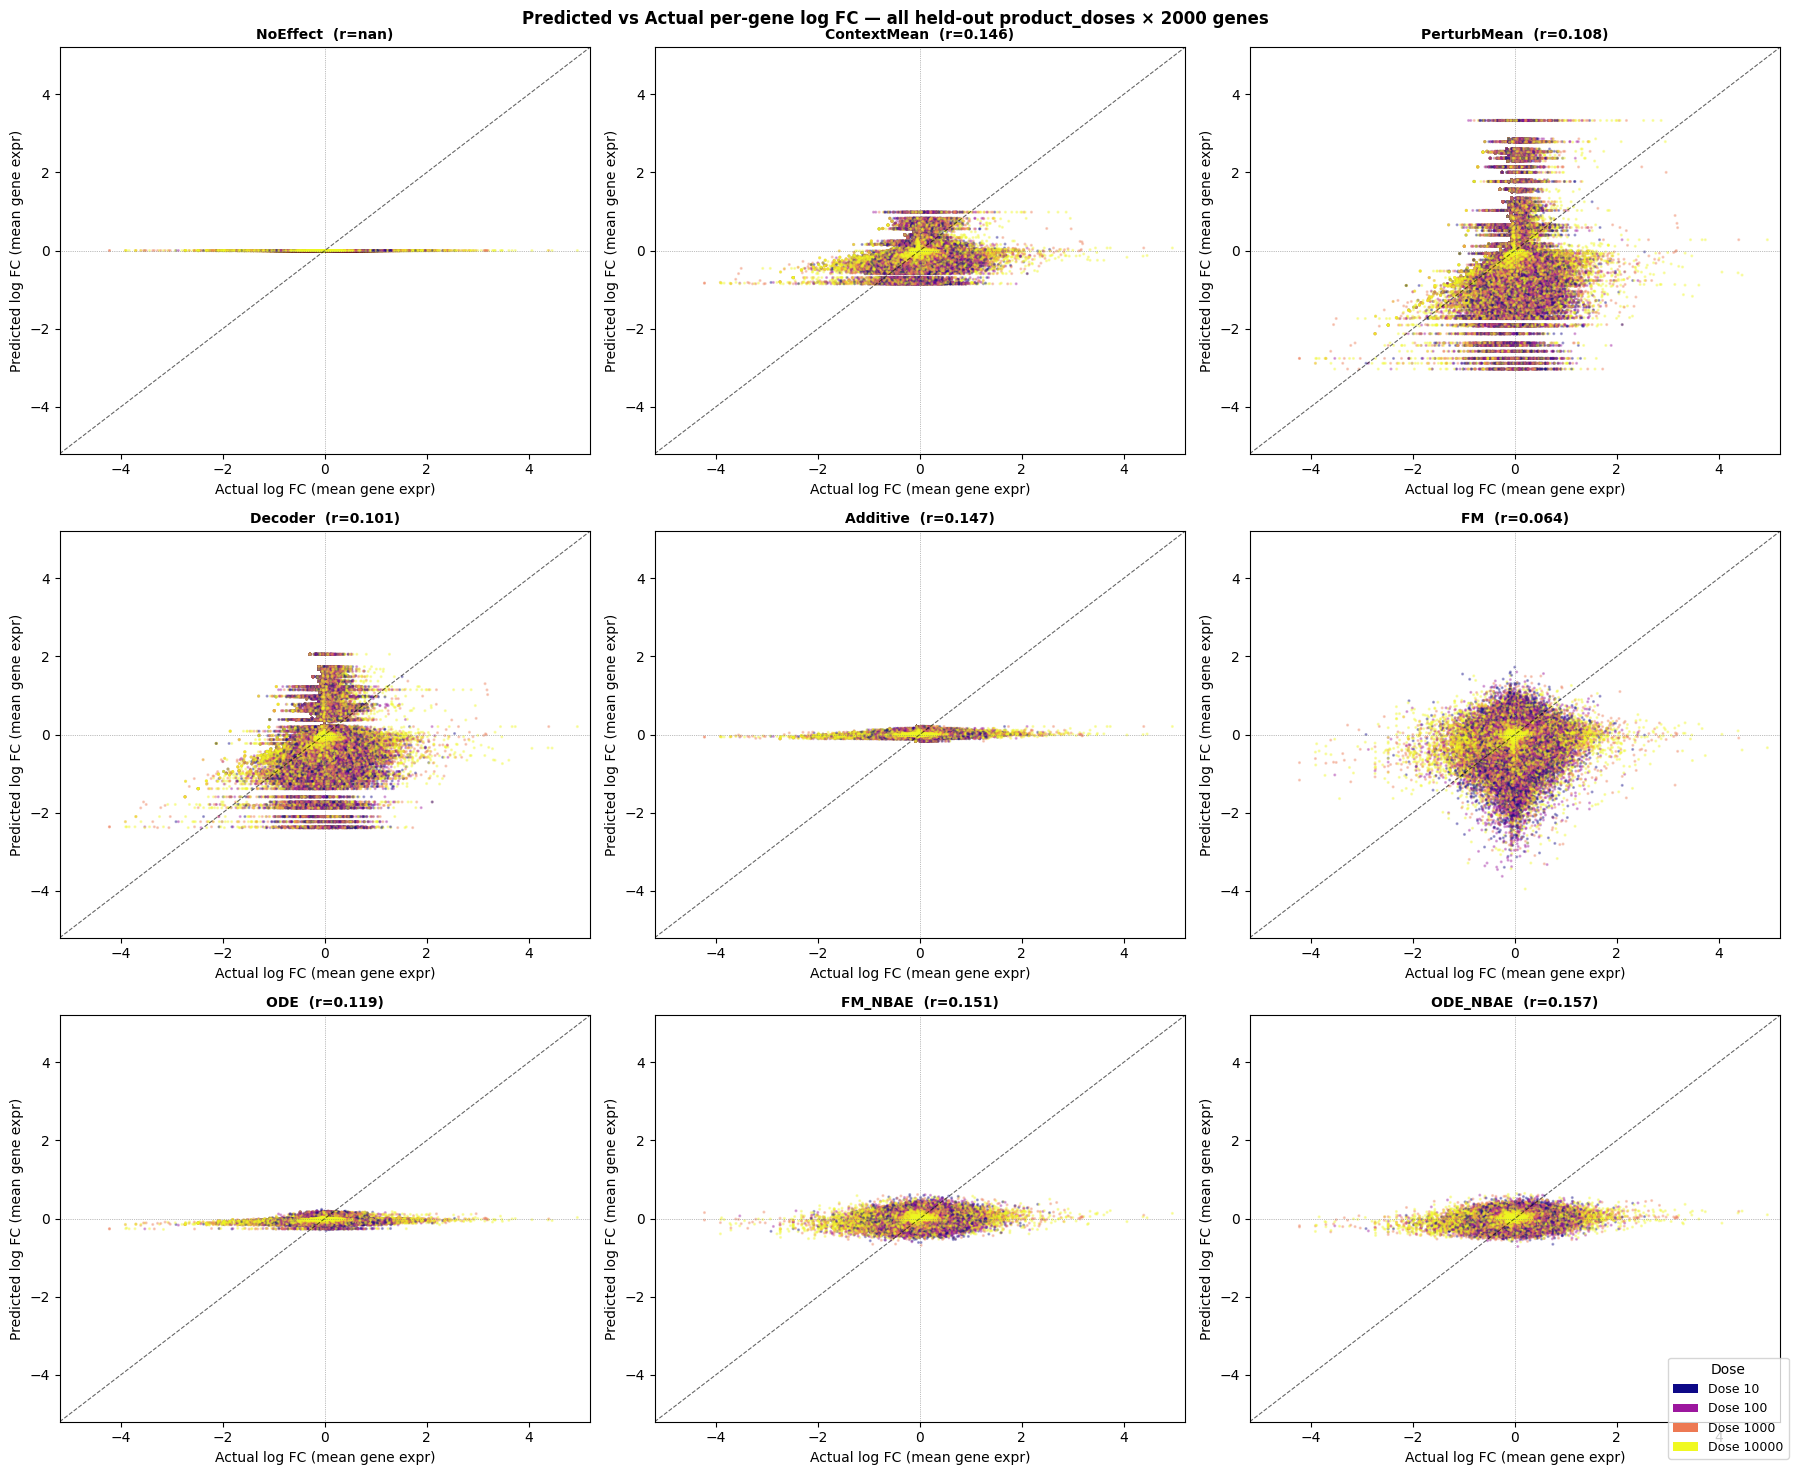

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# control mean in gene space (log1p-normalised, same preprocessing for all models)
mu_ctrl = x_ctrl_test.numpy().mean(axis=0)  # (n_genes,)

baseline_names = list(results.keys())
n_models = len(baseline_names)

DOSE_LEVELS = sorted({results[n][pd]["dose"] for n in results for pd in results[n]})
DOSE_CMAP = plt.cm.get_cmap("plasma", len(DOSE_LEVELS))
DOSE_COLOR = {d: DOSE_CMAP(i) for i, d in enumerate(DOSE_LEVELS)}

ncols = 3
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

for ax_idx, name in enumerate(baseline_names):
    ax = axes[ax_idx]

    # collect all (actual_logfc, pred_logfc, dose) across every pd_str
    all_actual, all_pred, all_dose_color = [], [], []
    for pd_str, scores in results[name].items():
        dose = scores["dose"]
        color = DOSE_COLOR[dose]

        mu_gt = scores["x_gt"].mean(axis=0)  # (n_genes,)
        mu_pred = scores["x_pred"].mean(axis=0)

        actual_lfc = mu_gt - mu_ctrl
        pred_lfc = mu_pred - mu_ctrl

        all_actual.append(actual_lfc)
        all_pred.append(pred_lfc)
        all_dose_color.extend([color] * len(actual_lfc))

    all_actual = np.concatenate(all_actual)
    all_pred = np.concatenate(all_pred)

    ax.scatter(all_actual, all_pred, c=all_dose_color, s=1.5, alpha=0.3, rasterized=True)

    # diagonal y=x reference
    lim = max(np.abs(all_actual).max(), np.abs(all_pred).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", linewidth=0.8, alpha=0.6)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    # pearson r
    r = np.corrcoef(all_actual, all_pred)[0, 1]
    ax.set_title(f"{name}  (r={r:.3f})", fontweight="bold", fontsize=10)
    ax.set_xlabel("Actual log FC (mean gene expr)")
    ax.set_ylabel("Predicted log FC (mean gene expr)")
    ax.axhline(0, color="grey", linewidth=0.5, linestyle=":")
    ax.axvline(0, color="grey", linewidth=0.5, linestyle=":")

# hide unused axes
for ax_idx in range(n_models, len(axes)):
    axes[ax_idx].set_visible(False)

# shared legend for doses
legend_patches = [mpatches.Patch(facecolor=DOSE_COLOR[d], label=f"Dose {int(d)}") for d in DOSE_LEVELS]
fig.legend(
    handles=legend_patches,
    loc="lower right",
    fontsize=9,
    title="Dose",
    bbox_to_anchor=(1.0, 0.01),
)

plt.suptitle(
    f"Predicted vs Actual per-gene log FC — all held-out product_doses × {len(hvg_names)} genes",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


Significant gene × perturbation pairs: 29964 (FDR < 0.05, across 375 product_doses × 2000 genes)


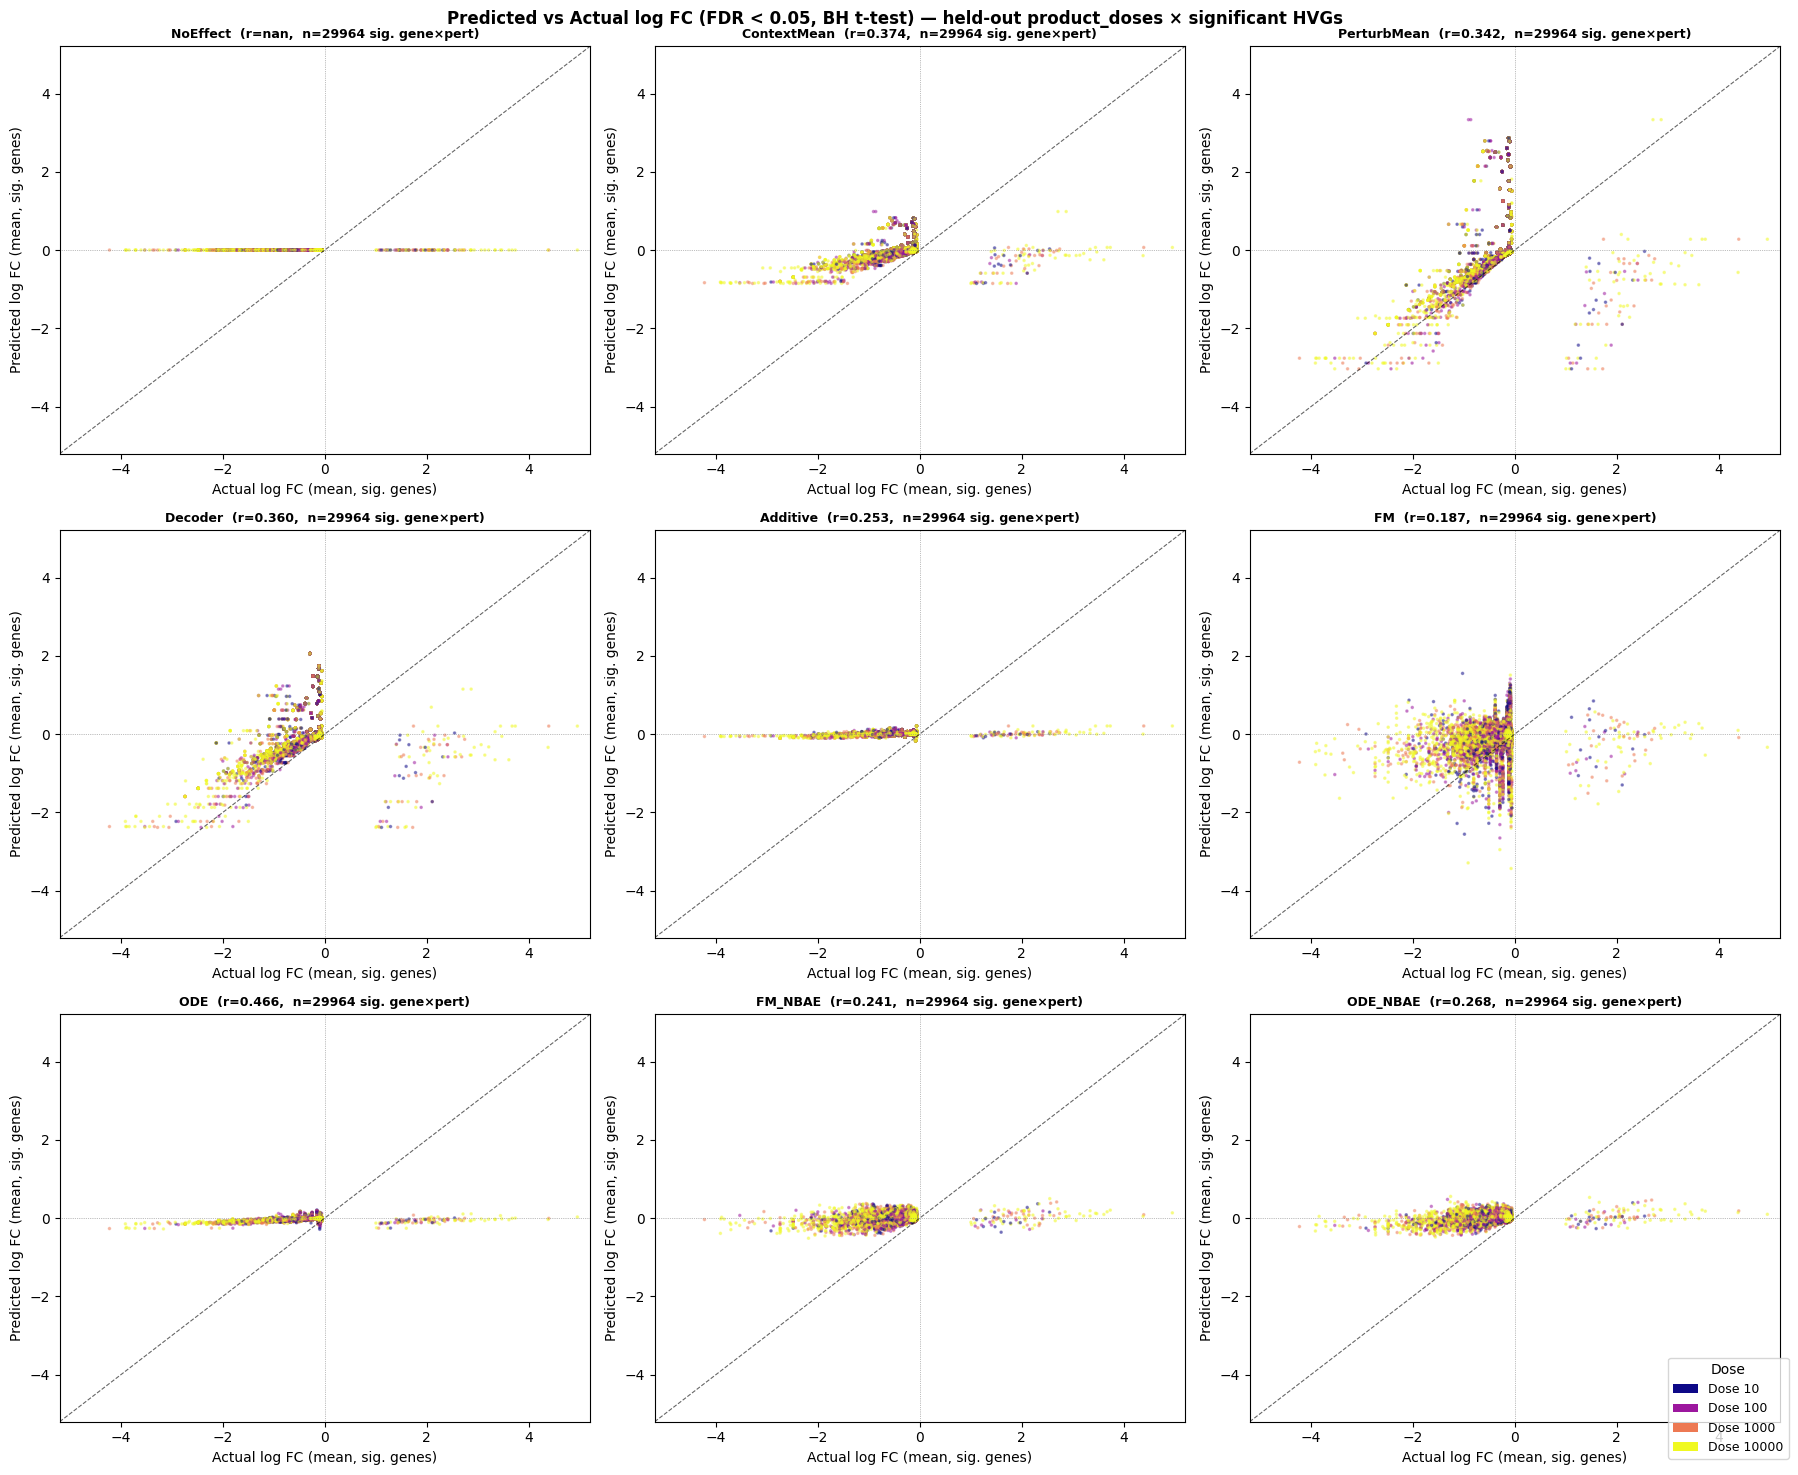

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats
from scipy.stats import false_discovery_control

# ── Parameters ────────────────────────────────────────────────────────────────
FDR_ALPHA = 0.05  # BH-adjusted p-value threshold
MIN_CELLS = 5  # minimum cells per group to run the t-test

mu_ctrl = x_ctrl_test.numpy().mean(axis=0)  # (n_genes,)
x_ctrl_arr = x_ctrl_test.numpy()  # (n_ctrl, n_genes)

baseline_names = list(results.keys())
n_models = len(baseline_names)

DOSE_LEVELS = sorted({results[n][pd]["dose"] for n in results for pd in results[n]})
DOSE_CMAP = plt.cm.get_cmap("plasma", len(DOSE_LEVELS))
DOSE_COLOR = {d: DOSE_CMAP(i) for i, d in enumerate(DOSE_LEVELS)}


def significant_gene_mask(x_ctrl_arr: np.ndarray, x_gt_arr: np.ndarray, fdr: float = FDR_ALPHA) -> np.ndarray:
    """Return boolean mask of genes with BH-significant t-test (pert vs ctrl).

    Args:
        x_ctrl_arr: Control expression matrix (n_ctrl, n_genes).
        x_gt_arr: Perturbed expression matrix (n_pert, n_genes).
        fdr: BH FDR threshold.

    Returns:
        Boolean array of shape (n_genes,); True = significant.
    """
    if x_ctrl_arr.shape[0] < MIN_CELLS or x_gt_arr.shape[0] < MIN_CELLS:
        return np.zeros(x_ctrl_arr.shape[1], dtype=bool)
    _, pvals = stats.ttest_ind(x_gt_arr, x_ctrl_arr, axis=0, equal_var=False)
    pvals = np.nan_to_num(pvals, nan=1.0)
    adj_pvals = false_discovery_control(pvals, method="bh")
    return adj_pvals < fdr


# Pre-compute significant gene masks per product_dose (use first model's x_gt)
_ref_name = baseline_names[0]
sig_masks = {}
for pd_str, scores in results[_ref_name].items():
    sig_masks[pd_str] = significant_gene_mask(x_ctrl_arr, scores["x_gt"])

total_sig = sum(m.sum() for m in sig_masks.values())
print(
    f"Significant gene × perturbation pairs: {total_sig} "
    f"(FDR < {FDR_ALPHA}, across {len(sig_masks)} product_doses × {x_ctrl_arr.shape[1]} genes)"
)

# ── Plot ───────────────────────────────────────────────────────────────────────
ncols = 3
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

for ax_idx, name in enumerate(baseline_names):
    ax = axes[ax_idx]

    all_actual, all_pred, all_dose_color = [], [], []
    for pd_str, scores in results[name].items():
        mask = sig_masks[pd_str]
        if mask.sum() == 0:
            continue
        dose = scores["dose"]
        color = DOSE_COLOR[dose]

        mu_gt = scores["x_gt"].mean(axis=0)
        mu_pred = scores["x_pred"].mean(axis=0)

        actual_lfc = (mu_gt - mu_ctrl)[mask]
        pred_lfc = (mu_pred - mu_ctrl)[mask]

        all_actual.append(actual_lfc)
        all_pred.append(pred_lfc)
        all_dose_color.extend([color] * mask.sum())

    if not all_actual:
        ax.set_title(f"{name}  (no sig. genes)", fontweight="bold", fontsize=10)
        continue

    all_actual = np.concatenate(all_actual)
    all_pred = np.concatenate(all_pred)

    ax.scatter(all_actual, all_pred, c=all_dose_color, s=2.5, alpha=0.4, rasterized=True)

    lim = max(np.abs(all_actual).max(), np.abs(all_pred).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", linewidth=0.8, alpha=0.6)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    r = np.corrcoef(all_actual, all_pred)[0, 1]
    ax.set_title(
        f"{name}  (r={r:.3f},  n={len(all_actual)} sig. gene×pert)",
        fontweight="bold",
        fontsize=9,
    )
    ax.set_xlabel("Actual log FC (mean, sig. genes)")
    ax.set_ylabel("Predicted log FC (mean, sig. genes)")
    ax.axhline(0, color="grey", linewidth=0.5, linestyle=":")
    ax.axvline(0, color="grey", linewidth=0.5, linestyle=":")

for ax_idx in range(n_models, len(axes)):
    axes[ax_idx].set_visible(False)

legend_patches = [mpatches.Patch(facecolor=DOSE_COLOR[d], label=f"Dose {int(d)}") for d in DOSE_LEVELS]
fig.legend(handles=legend_patches, loc="lower right", fontsize=9, title="Dose", bbox_to_anchor=(1.0, 0.01))

plt.suptitle(
    f"Predicted vs Actual log FC (FDR < {FDR_ALPHA}, BH t-test) — held-out product_doses × significant HVGs",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd
import numpy as np

# ── Pearson r summary table (overall genes vs DEGs) ───────────────────────────
# sig_masks and mu_ctrl computed in previous cell; reuse them here.

baseline_names = list(results.keys())

rows = []
for name in baseline_names:
    all_actual_all, all_pred_all = [], []
    all_actual_deg, all_pred_deg = [], []

    for pd_str, scores in results[name].items():
        mu_gt = scores["x_gt"].mean(axis=0)
        mu_pred = scores["x_pred"].mean(axis=0)

        actual_lfc = mu_gt - mu_ctrl
        pred_lfc = mu_pred - mu_ctrl

        all_actual_all.append(actual_lfc)
        all_pred_all.append(pred_lfc)

        mask = sig_masks[pd_str]
        if mask.sum() > 0:
            all_actual_deg.append(actual_lfc[mask])
            all_pred_deg.append(pred_lfc[mask])

    a_all = np.concatenate(all_actual_all)
    p_all = np.concatenate(all_pred_all)
    r_all = float(np.corrcoef(a_all, p_all)[0, 1])

    if all_actual_deg:
        a_deg = np.concatenate(all_actual_deg)
        p_deg = np.concatenate(all_pred_deg)
        r_deg = float(np.corrcoef(a_deg, p_deg)[0, 1])
        n_deg = len(a_deg)
    else:
        r_deg = float("nan")
        n_deg = 0

    rows.append(
        {
            "Model": name,
            "Pearson r (all genes)": r_all,
            f"Pearson r (DEGs, FDR<{FDR_ALPHA})": r_deg,
            "N DEG×pert pairs": n_deg,
        }
    )

# Transpose: metrics as rows, models as columns
df_r = pd.DataFrame(rows).set_index("Model").T
df_r.index.name = "Metric"

# ── Style: bold best (highest r) per Pearson row ─────────────────────────────
r_rows = [idx for idx in df_r.index if idx.startswith("Pearson")]
best_r = {row: df_r.loc[row].idxmax() for row in r_rows}


def apply_style(row):
    if row.name not in best_r:
        return [""] * len(row)
    return ["font-weight: bold; background-color: #d4f1d4" if col == best_r[row.name] else "" for col in row.index]


def fmt_val(v):
    """Format a cell value, handling NaN and integer-valued floats."""
    if isinstance(v, float):
        if np.isnan(v):
            return "—"
        # integer-valued floats (e.g. N DEG counts stored as float after transpose)
        if v == int(v):
            return f"{int(v):,}"
        return f"{v:.4f}"
    return str(v)


styled_r = (
    df_r.style.apply(apply_style, axis=1)
    .format(fmt_val)
    .set_caption(
        f"Log FC Pearson r — all genes vs DEGs (FDR < {FDR_ALPHA}, BH Welch t-test). Bold = best model per metric."
    )
    .set_table_styles(
        [
            {"selector": "caption", "props": [("font-size", "12px"), ("font-weight", "bold"), ("text-align", "left")]},
            {"selector": "th", "props": [("text-align", "center"), ("font-size", "11px")]},
            {"selector": "td", "props": [("text-align", "center"), ("font-size", "11px")]},
        ]
    )
)

display(styled_r)


Model,NoEffect,ContextMean,PerturbMean,Decoder,Additive,FM,ODE,FM_NBAE,ODE_NBAE
Metric,,,,,,,,,
Pearson r (all genes),—,0.1464,0.1076,0.1007,0.1473,0.0636,0.1192,0.1508,0.1570
"Pearson r (DEGs, FDR<0.05)",—,0.3740,0.3416,0.3601,0.2530,0.1865,0.4657,0.2410,0.2682
N DEG×pert pairs,"29,964","29,964","29,964","29,964","29,964","29,964","29,964","29,964","29,964"
